In [1]:
import xarray as xr

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import xgcm
from typing import Annotated
from xhistogram.xarray import histogram
import xrft
from xgcm import Grid
from matplotlib.gridspec import GridSpec

from matplotlib.colors import BoundaryNorm

In [2]:
def open_llc4320_velocity_data(chunks='auto', time_range=None):
    
    ds_SSU = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/ssu", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    ds_SSV = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/ssv", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    # Open grid data
    ds_grid = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/grid", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    coords_to_keep = ['XC', 'YC', 'dxC', 'dyC', 'dxG', 'dyG', 'rAz', 'rA', 'Depth']
    ds_grid = ds_grid.reset_coords()[coords_to_keep]
    
    ds = xr.merge([ds_SSU, ds_SSV, ds_grid])
    
    if time_range is not None:
        ds = ds.isel(time=time_range)
        
    ds = ds.chunk(chunks)
    
    return ds, ds_grid

In [3]:
ds, ds_grid = open_llc4320_velocity_data(chunks={})

In [4]:
grid = xgcm.Grid(ds_grid, periodic=False)

In [5]:
@xgcm.as_grid_ufunc(
    boundary_width={"X": (1, 0), "Y": (1, 0)},
    boundary="fill",
    fill_value=np.nan,
    dask="parallelized",    
)
def vort(
    u:   Annotated[np.ndarray, "(Y:center,X:left)"],
    dxc: Annotated[np.ndarray, "(Y:center,X:left)"],
    v:   Annotated[np.ndarray, "(Y:left,X:center)"],
    dyc: Annotated[np.ndarray, "(Y:left,X:center)"],
    raz: Annotated[np.ndarray, "(Y:left,X:left)"],
) ->     Annotated[np.ndarray, "(Y:left,X:left)"]:
    """Dimensional vorticity"""
    
    u_trans = u * dxc
    v_trans = v * dyc
    v_diff_x = v_trans[..., 1:, 1:] - v_trans[..., 1:, :-1]
    u_diff_y = u_trans[..., 1:, 1:] - u_trans[..., :-1, 1:]
    return (v_diff_x - u_diff_y) / raz[..., 1:, 1:]

@xgcm.as_grid_ufunc(
    boundary_width={"X": (1, 0), "Y": (1, 0)},
    boundary="fill",
    fill_value=np.nan,
    dask="parallelized",    
)
def strain(
    u:   Annotated[np.ndarray, "(Y:center,X:left)"],
    dxc: Annotated[np.ndarray, "(Y:center,X:left)"],
    v:   Annotated[np.ndarray, "(Y:left,X:center)"],
    dyc: Annotated[np.ndarray, "(Y:left,X:center)"],
) ->     Annotated[np.ndarray, "(Y:left,X:left)"]:
    u_diff_x = (u[..., 1:] - u[..., :-1]) / dxc[..., 1:]
    v_diff_x = (v[..., 1:] - v[..., :-1]) / dxc[..., 1:]
    u_diff_y = (u[..., 1:, :] - u[..., :-1, :]) / dyc[..., 1:, :]
    v_diff_y = (v[..., 1:, :] - v[..., :-1, :]) / dyc[..., 1:, :]
    
    u_diff_x_trimmed = u_diff_x[..., 1:, :]
    v_diff_x_trimmed = v_diff_x[..., 1:, :]
    u_diff_y_trimmed = u_diff_y[..., 1:]
    v_diff_y_trimmed = v_diff_y[..., 1:]
    
    strain_normal = u_diff_x_trimmed - v_diff_y_trimmed
    strain_shear = v_diff_x_trimmed + u_diff_y_trimmed
    
    # TODO: interpolate the shear strain onto the positions of the normal strain
    # For now, we just pretend they are at the same grid point
    strain_mag = np.sqrt(strain_normal ** 2 +  strain_shear ** 2)
    
    return strain_mag

@xgcm.as_grid_ufunc(
    boundary_width={"X": (1, 0), "Y": (1, 0)},
    boundary="fill",
    fill_value=np.nan,
    dask="parallelized",
)
def divergence(
    u:   Annotated[np.ndarray, "(Y:center,X:left)"],
    dxg: Annotated[np.ndarray, "(Y:left,X:center)"],
    v:   Annotated[np.ndarray, "(Y:left,X:center)"],
    dyg: Annotated[np.ndarray, "(Y:center,X:left)"],
    ra:  Annotated[np.ndarray, "(Y:center,X:center)"],
) ->     Annotated[np.ndarray, "(Y:center,X:center)"]:
    
    u_diff_x = (u[..., 1:] - u[..., :-1]) * dxg[..., 1:]
    v_diff_y = (v[..., 1:, :] - v[..., :-1, :]) * dyg[..., 1:, :]
    
    u_diff_x_trimmed = u_diff_x[..., 1:, :]
    v_diff_y_trimmed = v_diff_y[..., 1:]
    
    divergence = (u_diff_x_trimmed + v_diff_y_trimmed) / ra[..., 1:, 1:]
    
    return divergence

def vort_strain_div_bins(n_strain_bins=100, n_vort_bins=200, n_div_bins=200, vort_max=5, strain_max=5, div_max=5):
    vort_bins = np.linspace(-vort_max, vort_max, n_vort_bins)
    strain_bins = np.linspace(0.0, strain_max, n_strain_bins)
    div_bins = np.linspace(-div_max, div_max, n_div_bins)
    return vort_bins, strain_bins, div_bins

In [6]:
def marginalize(pdf: xr.DataArray, dims: str | list = None) -> xr.DataArray:
    """
    Integrate out one or more dimensions of the PDF to remove dependence on that quantity,
    whilst still preserving the total integrated probability.
    """
       
    all_bin_dims = ['vort_bin', 'strain_bin', 'div_bin']
    
    if isinstance(dims, str):
        dims = [dims]
    
    if dims is None:
        dims=all_bin_dims
    
    if any(d not in all_bin_dims for d in dims):
        raise ValueError("Can't take marginal PDF over a dimension which is not a variable of the original PDF")
    
    marginal_pdf = pdf

    # TODO these might be more accurate if we used xarray's integrate function
    if 'vort_bin' in dims:
        vort_bin_width = pdf['vort_bin'].diff('vort_bin')[0]
        marginal_pdf = marginal_pdf.sum(dim='vort_bin') * vort_bin_width
        
    if 'strain_bin' in dims:
        strain_bin_width = pdf['strain_bin'].diff('strain_bin')[0]
        marginal_pdf = marginal_pdf.sum(dim='strain_bin') * strain_bin_width
        
    if 'div_bin' in dims:
        div_bin_width = pdf['div_bin'].diff('div_bin')[0]
        marginal_pdf = marginal_pdf.sum(dim='div_bin') * div_bin_width
        
    return marginal_pdf

def expectation(pdf: xr.DataArray, x: xr.DataArray, dims: str | list = None) -> xr.DataArray:
    """
    Take the expectation value of x over the given Probability Density Function.
    """
    
    return marginalize(pdf * x, dims=dims)

In [7]:
@xr.register_dataarray_accessor("pdf")
class DataArrayPDFAccessor:
    def __init__(self, da: xr.DataArray):
        self._da = da
        
    def marginalize(self, dims: str | list = None) -> xr.DataArray:
        return marginalize(self._da, dims=dims)
    
    def expectation(self, x, dims: str | list = None) -> xr.DataArray:
        return expectation(self._da, x, dims=dims)

In [8]:
vort_bins, strain_bins, div_bins = vort_strain_div_bins(n_strain_bins=50, n_vort_bins=100, n_div_bins=100)
a = np.diff(vort_bins)[0]*np.diff(strain_bins)[0]*np.diff(div_bins)[0]

In [9]:
t_start = 8500
tdiff = 120
tstep=1
i_extent_eq = slice(0,540)
j_extent_eq = slice(3780,4320)

ds_eq = ds.isel(time=slice(t_start,t_start+tdiff,tstep)).drop_vars('time').sel(face=1).isel(i_g=i_extent_eq).isel(j_g=j_extent_eq
                                                                                                                  ).isel(i=i_extent_eq).isel(j=j_extent_eq)
ds_eq

<xarray.Dataset> Size: 290MB
Dimensions:  (time: 120, j: 540, i_g: 540, j_g: 540, i: 540)
Coordinates:
  * j        (j) int64 4kB 3780 3781 3782 3783 3784 ... 4315 4316 4317 4318 4319
  * i_g      (i_g) int64 4kB 0 1 2 3 4 5 6 7 ... 532 533 534 535 536 537 538 539
  * j_g      (j_g) int64 4kB 3780 3781 3782 3783 3784 ... 4316 4317 4318 4319
  * i        (i) int64 4kB 0 1 2 3 4 5 6 7 8 ... 532 533 534 535 536 537 538 539
    face     int64 8B 1
Dimensions without coordinates: time
Data variables:
    U        (time, j, i_g) float32 140MB dask.array<chunksize=(1, 540, 540), meta=np.ndarray>
    V        (time, j_g, i) float32 140MB dask.array<chunksize=(1, 540, 540), meta=np.ndarray>
    XC       (j, i) float32 1MB dask.array<chunksize=(540, 540), meta=np.ndarray>
    YC       (j, i) float32 1MB dask.array<chunksize=(540, 540), meta=np.ndarray>
    dxC      (j, i_g) float32 1MB dask.array<chunksize=(540, 540), meta=np.ndarray>
    dyC      (j_g, i) float32 1MB dask.array<chunksize=(540, 540), meta=np.ndarray>
    dxG      (j_g, i) float32 1MB dask.array<chunksize=(540, 540), meta=np.ndarray>
    dyG      (j, i_g) float32 1MB dask.array<chunksize=(540, 540), meta=np.ndarray>
    rAz      (j_g, i_g) float32 1MB dask.array<chunksize=(540, 540), meta=np.ndarray>
    rA       (j, i) float32 1MB dask.array<chunksize=(540, 540), meta=np.ndarray>
    Depth    (j, i) float32 1MB dask.array<chunksize=(540, 540), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      Created by calling `open_mdsdataset(llc_method='smallchunks...
    source:       MITgcm
    title:        netCDF wrapper of MITgcm MDS binary data

In [10]:
# Define model: A*cos(ωt) + B*sin(ωt)
T_M2_hours = 12.42
T_M4_hours = 12.42/2
T_M6_hours = 12.42/3
T_M8_hours = 12.42/4
T_M10_hours = 12.42/5
T_M12_hours = 12.42/6
omega = 2 * np.pi / T_M2_hours
omega4 = 2 * np.pi / T_M4_hours
omega6 = 2 * np.pi / T_M6_hours
omega8 = 2 * np.pi / T_M8_hours
omega10 = 2 * np.pi / T_M10_hours
omega12 = 2 * np.pi / T_M12_hours

def mtot_model(t, A, B, A4, B4, A6, B6, A8, B8, A10, B10, A12, B12):
    return (A * np.cos(omega * t) + B * np.sin(omega * t)+
           A4 * np.cos(omega4 * t) + B4 * np.sin(omega4 * t)+
           A6 * np.cos(omega6 * t) + B6 * np.sin(omega6 * t)+
           A8 * np.cos(omega8 * t) + B8 * np.sin(omega8 * t)+
           A10 * np.cos(omega10 * t) + B10 * np.sin(omega10 * t)+
           A12 * np.cos(omega12 * t) + B12 * np.sin(omega12 * t))

fittot = xr.open_dataset('fittot.nc')
fitvtotv = xr.open_dataset('fitvtotv.nc')
#fittot = ds_eq.U.load().curvefit(
#    coords={"time": ds_eq.time},
#    func=mtot_model,
#    param_names=["A", "B", "A4", "B4", "A6", "B6", "A8", "B8", "A10", "B10", "A12", "B12"],
#)

#fitvtotv = ds_eq.V.load().curvefit(
#    coords={"time": ds_eq.time},
#    func=mtot_model,
#    param_names=["A", "B", "A4", "B4", "A6", "B6", "A8", "B8", "A10", "B10", "A12", "B12"],
#)

In [11]:
A = fittot.curvefit_coefficients.sel(param="A")
B = fittot.curvefit_coefficients.sel(param="B")
A4 = fittot.curvefit_coefficients.sel(param="A4")
B4 = fittot.curvefit_coefficients.sel(param="B4")
A6 = fittot.curvefit_coefficients.sel(param="A6")
B6 = fittot.curvefit_coefficients.sel(param="B6")
A8 = fittot.curvefit_coefficients.sel(param="A8")
B8 = fittot.curvefit_coefficients.sel(param="B8")
A10 = fittot.curvefit_coefficients.sel(param="A10")
B10 = fittot.curvefit_coefficients.sel(param="B10")
A12 = fittot.curvefit_coefficients.sel(param="A12")
B12 = fittot.curvefit_coefficients.sel(param="B12")
tidalM2_Utot = mtot_model(ds_eq.U.time, A, B, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)
tidalM4_Utot = mtot_model(ds_eq.U.time, A, B, A4, B4, 0, 0, 0, 0, 0, 0, 0, 0)
tidal_Utot = mtot_model(ds_eq.U.time, A, B, A4, B4, A6, B6, A8, B8, A10, B10, A12, B12)


Av = fitvtotv.curvefit_coefficients.sel(param="A")
Bv = fitvtotv.curvefit_coefficients.sel(param="B")
Av4 = fitvtotv.curvefit_coefficients.sel(param="A4")
Bv4 = fitvtotv.curvefit_coefficients.sel(param="B4")
Av6 = fitvtotv.curvefit_coefficients.sel(param="A6")
Bv6 = fitvtotv.curvefit_coefficients.sel(param="B6")
Av8 = fitvtotv.curvefit_coefficients.sel(param="A8")
Bv8 = fitvtotv.curvefit_coefficients.sel(param="B8")
Av10 = fitvtotv.curvefit_coefficients.sel(param="A10")
Bv10 = fitvtotv.curvefit_coefficients.sel(param="B10")
Av12 = fitvtotv.curvefit_coefficients.sel(param="A12")
Bv12 = fitvtotv.curvefit_coefficients.sel(param="B12")
tidalM2_Vtot = mtot_model(ds_eq.V.time, Av, Bv, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)
tidalM4_Vtot = mtot_model(ds_eq.V.time, Av, Bv, Av4, Bv4, 0, 0, 0, 0, 0, 0, 0, 0)
tidal_Vtot = mtot_model(ds_eq.V.time, Av, Bv, Av4, Bv4, Av6, Bv6, Av8, Bv8, Av10, Bv10, Av12, Bv12)
#Av = fitv.curvefit_coefficients.sel(param="A")
#Bv = fitv.curvefit_coefficients.sel(param="B")
#tidal_V = m2_model(ds_eq.V.time, Av, Bv)

In [12]:
#tide_free_U = ds_eq.U - tidal_U
#tide_free_V = ds_eq.V - tidal_V
#tide_free = tide_free_U.rename('U').to_dataset().merge(tide_free_V.rename('V'))

#tide_free_U4 = tide_free_U - tidal_U4 - tidal_U6
#tide_free_V4 = tide_free_V - tidal_V4 - tidal_V6
#tide_free4 = tide_free_U4.rename('U').to_dataset().merge(tide_free_V4.rename('V'))

tideM2_only_U = tidalM2_Utot# + tidal_U4 + tidal_U6+ tidal_U8+ tidal_U10
tideM2_only_V = tidalM2_Vtot# + tidal_V4 + tidal_V6+ tidal_V8+ tidal_V10
tideM2_only = tideM2_only_U.rename('U').to_dataset().merge(tideM2_only_V.rename('V'),compat='override')

tideM4_only_U = tidalM4_Utot# + tidal_U4 + tidal_U6+ tidal_U8+ tidal_U10
tideM4_only_V = tidalM4_Vtot# + tidal_V4 + tidal_V6+ tidal_V8+ tidal_V10
tideM4_only = tideM4_only_U.rename('U').to_dataset().merge(tideM4_only_V.rename('V'),compat='override')


tide_only_U = tidal_Utot# + tidal_U4 + tidal_U6+ tidal_U8+ tidal_U10
tide_only_V = tidal_Vtot# + tidal_V4 + tidal_V6+ tidal_V8+ tidal_V10
tide_only = tide_only_U.rename('U').to_dataset().merge(tide_only_V.rename('V'),compat='override')

no_tide_U = ds_eq.U - tide_only_U
no_tide_V = ds_eq.V - tide_only_V
no_tide = no_tide_U .rename('U').to_dataset().merge(no_tide_V.rename('V'),compat='override')

In [13]:
grid_eq = xgcm.Grid(ds_eq, periodic=False)
ζ_piece_eq_tideM2only = vort(grid_eq, tideM2_only.U, ds_eq.dxC.load(), tideM2_only.V, ds_eq.dyC.load(), ds_eq.rAz.load(), axis= 5 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-5/2
σ_piece_eq_tideM2only = strain(grid_eq, tideM2_only.U, ds_eq.dxC.load(), tideM2_only.V, ds_eq.dyC.load(), axis=4 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-5/2
D_piece_eq_tideM2only = divergence(grid_eq, tideM2_only.U, ds_eq.dxG.load(), tideM2_only.V, ds_eq.dyG.load(), ds_eq.rA.load(), axis= 5 * [("Y", "X")])/10**-4


ζ_piece_eq_tideM4only = vort(grid_eq, tideM4_only.U, ds_eq.dxC.load(), tideM4_only.V, ds_eq.dyC.load(), ds_eq.rAz.load(), axis= 5 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-5/2
σ_piece_eq_tideM4only = strain(grid_eq, tideM4_only.U, ds_eq.dxC.load(), tideM4_only.V, ds_eq.dyC.load(), axis=4 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-5/2
D_piece_eq_tideM4only = divergence(grid_eq, tideM4_only.U, ds_eq.dxG.load(), tideM4_only.V, ds_eq.dyG.load(), ds_eq.rA.load(), axis= 5 * [("Y", "X")])/10**-4


ζ_piece_eq_tideonly = vort(grid_eq, tide_only.U, ds_eq.dxC.load(), tide_only.V, ds_eq.dyC.load(), ds_eq.rAz.load(), axis= 5 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-5/2
σ_piece_eq_tideonly = strain(grid_eq, tide_only.U, ds_eq.dxC.load(), tide_only.V, ds_eq.dyC.load(), axis=4 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-5/2
D_piece_eq_tideonly = divergence(grid_eq, tide_only.U, ds_eq.dxG.load(), tide_only.V, ds_eq.dyG.load(), ds_eq.rA.load(), axis= 5 * [("Y", "X")])/10**-4


ζ_piece_eq_notide = vort(grid_eq, no_tide.U.load(), ds_eq.dxC.load(), no_tide.V.load(), ds_eq.dyC.load(), ds_eq.rAz.load(), axis= 5 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-5/2
σ_piece_eq_notide = strain(grid_eq, no_tide.U, ds_eq.dxC.load(), no_tide.V, ds_eq.dyC.load(), axis=4 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-5/2
D_piece_eq_notide = divergence(grid_eq, no_tide.U, ds_eq.dxG.load(), no_tide.V, ds_eq.dyG.load(), ds_eq.rA.load(), axis= 5 * [("Y", "X")])/10**-4


ζ_piece_eq = vort(grid_eq, ds_eq.U.load(), ds_eq.dxC.load(), ds_eq.V.load(), ds_eq.dyC.load(), ds_eq.rAz.load(), axis= 5 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-5/2
σ_piece_eq = strain(grid_eq, ds_eq.U, ds_eq.dxC.load(), ds_eq.V, ds_eq.dyC.load(), axis=4 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-5/2
D_piece_eq = divergence(grid_eq, ds_eq.U, ds_eq.dxG.load(), ds_eq.V, ds_eq.dyG.load(), ds_eq.rA.load(), axis= 5 * [("Y", "X")])/10**-4

/tmp/ipykernel_353/2132151314.py:34: RuntimeWarning: invalid value encountered in divide
  u_diff_x = (u[..., 1:] - u[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_353/2132151314.py:35: RuntimeWarning: invalid value encountered in divide
  v_diff_x = (v[..., 1:] - v[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_353/2132151314.py:36: RuntimeWarning: invalid value encountered in divide
  u_diff_y = (u[..., 1:, :] - u[..., :-1, :]) / dyc[..., 1:, :]
/tmp/ipykernel_353/2132151314.py:37: RuntimeWarning: invalid value encountered in divide
  v_diff_y = (v[..., 1:, :] - v[..., :-1, :]) / dyc[..., 1:, :]


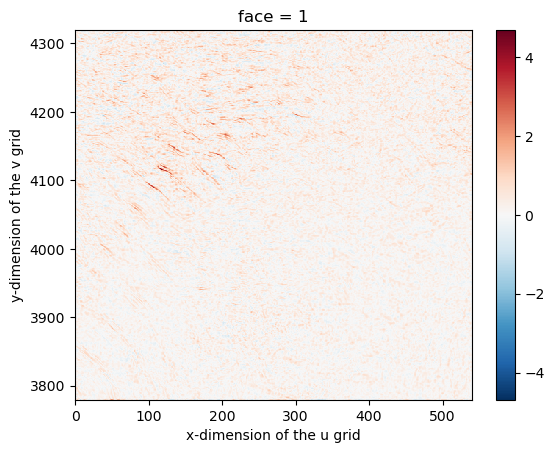

In [14]:
(σ_piece_eq_tideonly.isel(time=0)-σ_piece_eq_tideM2only.isel(time=0)).plot()

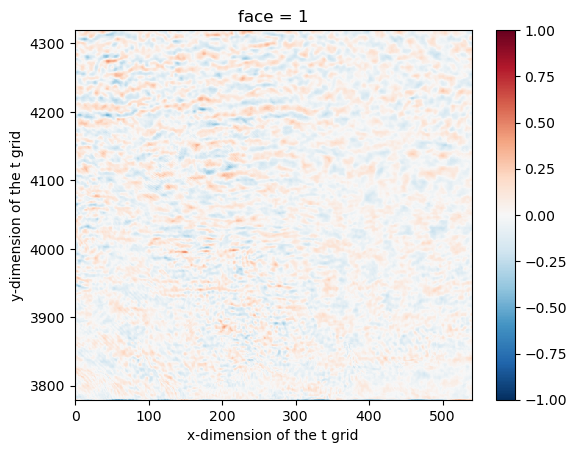

In [15]:
D_piece_eq_tideM2only.isel(time=0).plot(vmax=1)

In [14]:
h_eq = histogram(
    ζ_piece_eq.rename('vort'),
    σ_piece_eq.rename('strain'),
    D_piece_eq.rename('div'),
    bins=[vort_bins, strain_bins, div_bins],
    block_size=None,  # avoids a divide-by-zero bug in xhistogram's code for automatically determining block_size
    density=False,  # setting this to true leads to an error right now
    keep_coords=True,
)
h_eq = h_eq/a/550/550


h_eq_tideonly = histogram(
    ζ_piece_eq_tideonly.rename('vort'),
    σ_piece_eq_tideonly.rename('strain'),
    D_piece_eq_tideonly.rename('div'),
    bins=[vort_bins, strain_bins, div_bins],
    block_size=None,  # avoids a divide-by-zero bug in xhistogram's code for automatically determining block_size
    density=False,  # setting this to true leads to an error right now
    keep_coords=True,
)
h_eq_tideonly = h_eq_tideonly/a/550/550

h_eq_notide = histogram(
    ζ_piece_eq_notide.rename('vort'),
    σ_piece_eq_notide.rename('strain'),
    D_piece_eq_notide.rename('div'),
    bins=[vort_bins, strain_bins, div_bins],
    block_size=None,  # avoids a divide-by-zero bug in xhistogram's code for automatically determining block_size
    density=False,  # setting this to true leads to an error right now
    keep_coords=True,
)
h_eq_notide = h_eq_notide/a/550/550

h_eq_tideM2only = histogram(
    ζ_piece_eq_tideM2only.rename('vort'),
    σ_piece_eq_tideM2only.rename('strain'),
    D_piece_eq_tideM2only.rename('div'),
    bins=[vort_bins, strain_bins, div_bins],
    block_size=None,  # avoids a divide-by-zero bug in xhistogram's code for automatically determining block_size
    density=False,  # setting this to true leads to an error right now
    keep_coords=True,
)
h_eq_tideM2only = h_eq_tideM2only/a/550/550

h_eq_tideM4only = histogram(
    ζ_piece_eq_tideM4only.rename('vort'),
    σ_piece_eq_tideM4only.rename('strain'),
    D_piece_eq_tideM4only.rename('div'),
    bins=[vort_bins, strain_bins, div_bins],
    block_size=None,  # avoids a divide-by-zero bug in xhistogram's code for automatically determining block_size
    density=False,  # setting this to true leads to an error right now
    keep_coords=True,
)
h_eq_tideM4only = h_eq_tideM4only/a/550/550

In [15]:
h_DivPdf_eq = (h_eq*h_eq.div_bin).mean('div_bin').load()
h_DivPdf_eq_tideonly = (h_eq_tideonly*h_eq_tideonly.div_bin).mean('div_bin').load()
h_DivPdf_eq_notide = (h_eq_notide*h_eq_notide.div_bin).mean('div_bin').load()
h_DivPdf_eq_tideM2only = (h_eq_tideM2only*h_eq_tideM2only.div_bin).mean('div_bin').load()
h_DivPdf_eq_tideM4only = (h_eq_tideM4only*h_eq_tideM4only.div_bin).mean('div_bin').load()

In [16]:
#fittot.to_netcdf('fittot.nc')
#fitvtotv.to_netcdf('fitvtotv.nc')

In [17]:
lon_piece = ds.sel(face=1).isel(j=j_extent_eq).isel(i=i_extent_eq).XC.mean('j')
lat_piece = ds.sel(face=1).isel(j=j_extent_eq).isel(i=i_extent_eq).YC.mean('i')

In [18]:
from matplotlib.gridspec import GridSpec

<>:14: SyntaxWarning: invalid escape sequence '\z'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\z'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\z'
<>:39: SyntaxWarning: invalid escape sequence '\s'
<>:51: SyntaxWarning: invalid escape sequence '\z'
<>:52: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\z'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\z'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\z'
<>:39: SyntaxWarning: invalid escape sequence '\s'
<>:51: SyntaxWarning: invalid escape sequence '\z'
<>:52: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_353/1615895169.py:14: SyntaxWarning: invalid escape sequence '\z'
  plt.xlabel('$\zeta/f_{floor}$')
/tmp/ipykernel_353/1615895169.py:15: SyntaxWarning: invalid escape se

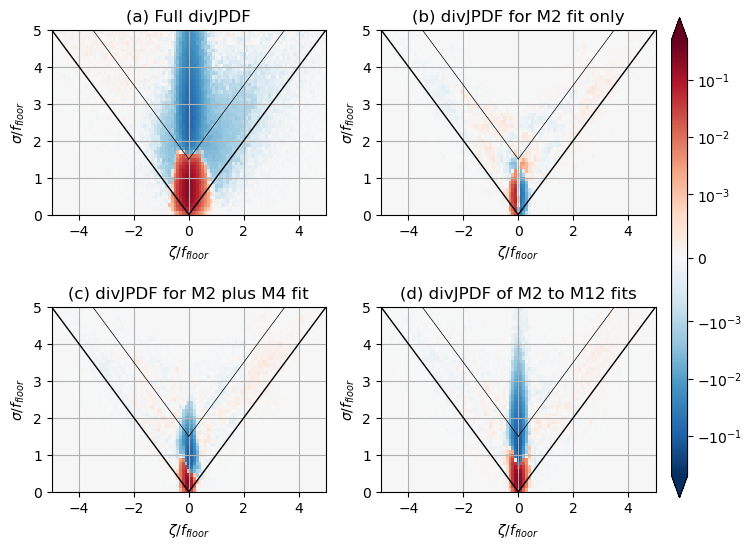

In [19]:
cmap = plt.get_cmap('seismic')

levels=np.arange(-1.5,1.501,0.05)
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
fig = plt.figure(figsize=(8,6))
ax1 = fig.add_subplot(221)
cs1=h_DivPdf_eq.plot.pcolormesh(x='vort_bin', vmax=0.5, norm=mpl.colors.SymLogNorm(1e-3),ax=ax1,add_colorbar=False)
plt.title('(a) Full divJPDF')
ax1.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1)
ax1.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1)
ax1.plot(np.linspace(0,3.5), np.linspace(1.5,5),color='k',linewidth=0.5)
ax1.plot(np.linspace(-3.5,0), np.linspace(5,1.5),color='k',linewidth=0.5)
ax1.grid()
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')


ax2 = fig.add_subplot(222)
cs1=h_DivPdf_eq_tideM2only.plot.pcolormesh(x='vort_bin', vmax=0.5, norm=mpl.colors.SymLogNorm(1e-3),ax=ax2,add_colorbar=False)
plt.title('(b) divJPDF for M2 fit only')
ax2.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1)
ax2.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1)
ax2.plot(np.linspace(0,3.5), np.linspace(1.5,5),color='k',linewidth=0.5)
ax2.plot(np.linspace(-3.5,0), np.linspace(5,1.5),color='k',linewidth=0.5)
ax2.grid()
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')


ax3 = fig.add_subplot(223)
cs1=h_DivPdf_eq_tideM4only.plot.pcolormesh(x='vort_bin', vmax=0.5, norm=mpl.colors.SymLogNorm(1e-3),ax=ax3,add_colorbar=False)
plt.title('(c) divJPDF for M2 plus M4 fit')
ax3.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1)
ax3.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1)
ax3.plot(np.linspace(0,3.5), np.linspace(1.5,5),color='k',linewidth=0.5)
ax3.plot(np.linspace(-3.5,0), np.linspace(5,1.5),color='k',linewidth=0.5)
ax3.grid()
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')



ax4 = fig.add_subplot(224)
cs1=h_DivPdf_eq_tideonly.plot.pcolormesh(x='vort_bin', vmax=0.5, norm=mpl.colors.SymLogNorm(1e-3),ax=ax4,add_colorbar=False)
plt.title('(d) divJPDF of M2 to M12 fits')
ax4.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1)
ax4.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1)
ax4.plot(np.linspace(0,3.5), np.linspace(1.5,5),color='k',linewidth=0.5)
ax4.plot(np.linspace(-3.5,0), np.linspace(5,1.5),color='k',linewidth=0.5)
ax4.grid()
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')


plt.subplots_adjust(wspace=0.2,hspace=0.5,right=0.88)

cbar_ax = fig.add_axes([0.9, 0.1, 0.02, 0.8])
fig.colorbar(cs1, cax=cbar_ax,extend='both')


#fig.suptitle("Equatorial region with internal tide beam", fontsize=14, y=0.95)

fig.savefig('eq-M2-fits-jpdf.png')

<>:22: SyntaxWarning: invalid escape sequence '\z'
<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\z'
<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\z'
<>:59: SyntaxWarning: invalid escape sequence '\s'
<>:78: SyntaxWarning: invalid escape sequence '\z'
<>:79: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\z'
<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\z'
<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\z'
<>:59: SyntaxWarning: invalid escape sequence '\s'
<>:78: SyntaxWarning: invalid escape sequence '\z'
<>:79: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_71/3107046605.py:22: SyntaxWarning: invalid escape sequence '\z'
  plt.xlabel('$\zeta/f_{floor}$')
/tmp/ipykernel_71/3107046605.py:23: SyntaxWarning: invalid escape sequ

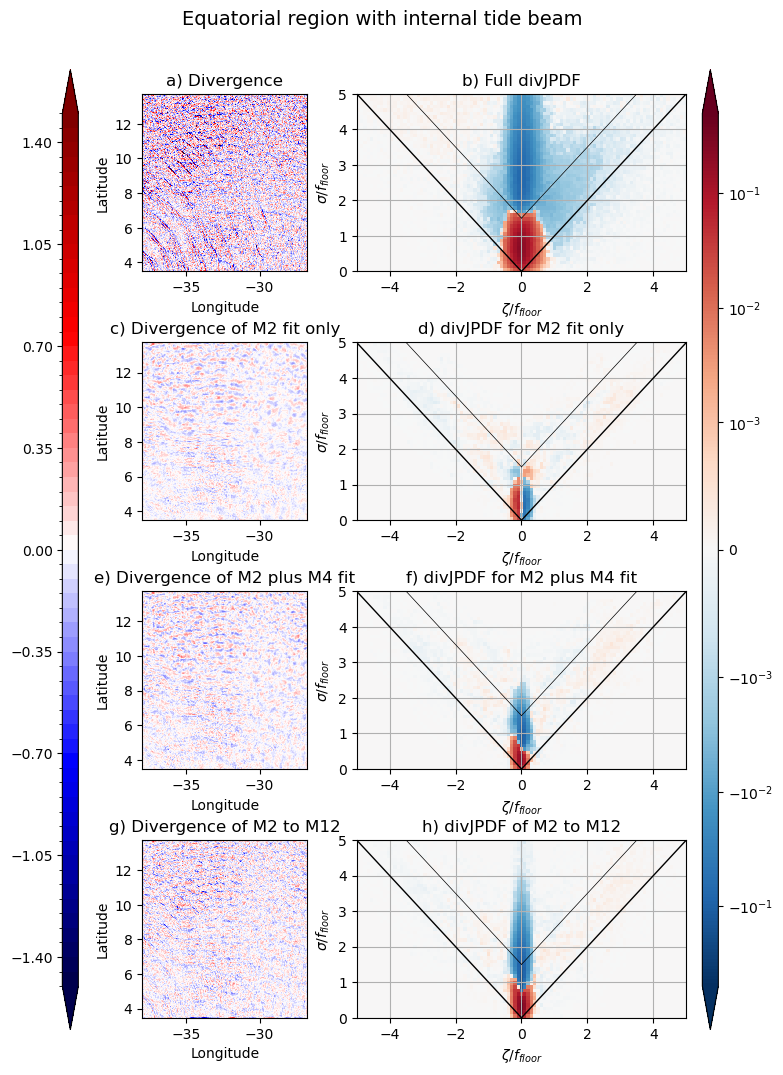

In [22]:
cmap = plt.get_cmap('seismic')
gs = GridSpec(4, 2, width_ratios=[1, 2], height_ratios=[1, 1, 1, 1], hspace=0.4)

levels=np.arange(-1.5,1.501,0.05)
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
fig = plt.figure(figsize=(8,12))
ax1 = fig.add_subplot(gs[0])
cs1=ax1.pcolormesh(lon_piece, lat_piece, D_piece_eq.isel(time=59),cmap='seismic',norm=norm,rasterized=True)
plt.title('a) Divergence')
plt.xlabel('Longitude')
plt.ylabel('Latitude')


ax2 = fig.add_subplot(gs[1])
cs1=h_DivPdf_eq.plot.pcolormesh(x='vort_bin', vmax=0.5, norm=mpl.colors.SymLogNorm(1e-3),ax=ax2,add_colorbar=False)
plt.title('b) Full divJPDF')
ax2.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1)
ax2.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1)
ax2.plot(np.linspace(0,3.5), np.linspace(1.5,5),color='k',linewidth=0.5)
ax2.plot(np.linspace(-3.5,0), np.linspace(5,1.5),color='k',linewidth=0.5)
ax2.grid()
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')

ax3 = fig.add_subplot(gs[2])
cs1=ax3.pcolormesh(lon_piece, lat_piece, D_piece_eq_tideM2only.isel(time=59),cmap='seismic',norm=norm,rasterized=True)
plt.title('c) Divergence of M2 fit only')
plt.xlabel('Longitude')
plt.ylabel('Latitude')


ax4 = fig.add_subplot(gs[3])
cs1=h_DivPdf_eq_tideM2only.plot.pcolormesh(x='vort_bin', vmax=0.5, norm=mpl.colors.SymLogNorm(1e-3),ax=ax4,add_colorbar=False)
plt.title('d) divJPDF for M2 fit only')
ax4.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1)
ax4.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1)
ax4.plot(np.linspace(0,3.5), np.linspace(1.5,5),color='k',linewidth=0.5)
ax4.plot(np.linspace(-3.5,0), np.linspace(5,1.5),color='k',linewidth=0.5)
ax4.grid()
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')

ax5 = fig.add_subplot(gs[4])
cs1=ax5.pcolormesh(lon_piece, lat_piece, D_piece_eq_tideM4only.isel(time=59),cmap='seismic',norm=norm,rasterized=True)
plt.title('e) Divergence of M2 plus M4 fit')
plt.xlabel('Longitude')
plt.ylabel('Latitude')


ax6 = fig.add_subplot(gs[5])
cs1=h_DivPdf_eq_tideM4only.plot.pcolormesh(x='vort_bin', vmax=0.5, norm=mpl.colors.SymLogNorm(1e-3),ax=ax6,add_colorbar=False)
plt.title('f) divJPDF for M2 plus M4 fit')
ax6.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1)
ax6.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1)
ax6.plot(np.linspace(0,3.5), np.linspace(1.5,5),color='k',linewidth=0.5)
ax6.plot(np.linspace(-3.5,0), np.linspace(5,1.5),color='k',linewidth=0.5)
ax6.grid()
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')



ax7 = fig.add_subplot(gs[6])
cs=ax7.pcolormesh(lon_piece, lat_piece, D_piece_eq_tideonly.isel(time=59),cmap='seismic',norm=norm,rasterized=True)
plt.title('g) Divergence of M2 to M12')
plt.xlabel('Longitude')
plt.ylabel('Latitude')


ax8 = fig.add_subplot(gs[7])
cs1=h_DivPdf_eq_tideonly.plot.pcolormesh(x='vort_bin', vmax=0.5, norm=mpl.colors.SymLogNorm(1e-3),ax=ax8,add_colorbar=False)
plt.title('h) divJPDF of M2 to M12')
ax8.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1)
ax8.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1)
ax8.plot(np.linspace(0,3.5), np.linspace(1.5,5),color='k',linewidth=0.5)
ax8.plot(np.linspace(-3.5,0), np.linspace(5,1.5),color='k',linewidth=0.5)
ax8.grid()
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')


plt.subplots_adjust(wspace=0.2,hspace=0.5,right=0.88,left=0.2)

cbar_ax = fig.add_axes([0.9, 0.1, 0.02, 0.8])
fig.colorbar(cs1, cax=cbar_ax,extend='both')

cbar_ax2 = fig.add_axes([0.1, 0.1, 0.02, 0.8])
fig.colorbar(cs, cax=cbar_ax2,extend='both')
cbar_ax2.yaxis.set_ticks_position('left')

fig.suptitle("Equatorial region with internal tide beam", fontsize=14, y=0.95)

fig.savefig('eq-M2-fits-jpdf.png')

In [9]:
U_fft = xrft.fft(ds_eq.U.load(),dim='time')
U_fft[69:72,:,:]=0
U_fft[49:52,:,:]=0
U_fft[78:82,:,:]=0
U_fft[39:43,:,:]=0
U_fft[88:92,:,:]=0
U_fft[29:33,:,:]=0
U_fft[98:101,:,:]=0
U_fft[20:23,:,:]=0
U_fft[108:111]=0
U_fft[10:13]=0

#U_fft[69:,:,:]=0
#U_fft[0:52,:,:]=0

V_fft = xrft.fft(ds_eq.V.load(),dim='time')
V_fft[69:72,:,:]=0
V_fft[49:52,:,:]=0
V_fft[78:82,:,:]=0
V_fft[39:43,:,:]=0
V_fft[88:92,:,:]=0
V_fft[29:33,:,:]=0
V_fft[98:101,:,:]=0
V_fft[20:23,:,:]=0
V_fft[108:111]=0
V_fft[10:13]=0

#V_fft[69:,:,:]=0
#V_fft[0:52,:,:]=0


KeyboardInterrupt



KeyboardInterrupt: 

In [ ]:
U_filtered = np.real(xrft.ifft(U_fft,dim='freq_time'))
V_filtered = np.real(xrft.ifft(V_fft,dim='freq_time'))
ds_filtered = U_filtered.rename('U').to_dataset().merge(V_filtered.rename('V'))

In [ ]:
(V_filtered-ds_eq.V).isel(time=60).plot()

In [ ]:
grid_eq = xgcm.Grid(ds_eq, periodic=False)
ζ_piece_eq = vort(grid_eq, ds_eq.U, ds_eq.dxC.load(), ds_eq.V, ds_eq.dyC.load(), ds_eq.rAz.load(), axis= 5 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-5/2
σ_piece_eq = strain(grid_eq, ds_eq.U, ds_eq.dxC.load(), ds_eq.V, ds_eq.dyC.load(), axis=4 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-5/2
D_piece_eq = divergence(grid_eq, ds_eq.U, ds_eq.dxG.load(), ds_eq.V, ds_eq.dyG.load(), ds_eq.rA.load(), axis= 5 * [("Y", "X")])/10**-4

ζ_piece_eq_filt = vort(grid_eq, ds_filtered.U, ds_eq.dxC.load(), ds_filtered.V, ds_eq.dyC.load(), ds_eq.rAz.load(), axis= 5 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-5/2
σ_piece_eq_filt = strain(grid_eq, ds_filtered.U, ds_eq.dxC.load(), ds_filtered.V, ds_eq.dyC.load(), axis=4 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-5/2
D_piece_eq_filt = divergence(grid_eq, ds_filtered.U, ds_eq.dxG.load(), ds_filtered.V, ds_eq.dyG.load(), ds_eq.rA.load(), axis= 5 * [("Y", "X")])/10**-4

In [ ]:
(D_piece_eq-D_piece_eq_filt).isel(time=0).plot()

In [ ]:
h_eq = histogram(
    ζ_piece_eq.rename('vort'),
    σ_piece_eq.rename('strain'),
    D_piece_eq.rename('div'),
    bins=[vort_bins, strain_bins, div_bins],
    block_size=None,  # avoids a divide-by-zero bug in xhistogram's code for automatically determining block_size
    density=False,  # setting this to true leads to an error right now
    keep_coords=True,
)
h_eq = h_eq/a/550/550

h_eq_filt = histogram(
    ζ_piece_eq_filt.rename('vort'),
    σ_piece_eq_filt.rename('strain'),
    D_piece_eq_filt.rename('div'),
    bins=[vort_bins, strain_bins, div_bins],
    block_size=None,  # avoids a divide-by-zero bug in xhistogram's code for automatically determining block_size
    density=False,  # setting this to true leads to an error right now
    keep_coords=True,
)
h_eq_filt = h_eq_filt/a/550/550


In [ ]:
h_vort_strain_eq = (h_eq.pdf.marginalize('div_bin')/97).load()
h_DivPdf_eq = (h_eq*h_eq.div_bin).mean('div_bin').load()

h_DivPdf_eq_filt = (h_eq_filt*h_eq_filt.div_bin).mean('div_bin').load()

#h_DivPdf_eq_tidefree4 = (h_eq_tidefree4*h_eq_tidefree4.div_bin).mean('div_bin').load()

In [ ]:
fig = plt.figure(figsize=(9, 5))

plt.subplot(221)
cs1=h_DivPdf_eq.plot.pcolormesh(x='vort_bin', vmax=0.5, norm=mpl.colors.SymLogNorm(1e-3),add_colorbar=False)
plt.title('Original')
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1)
plt.plot(np.linspace(0,3.5), np.linspace(1.5,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-3.5,0), np.linspace(5,1.5),color='k',linewidth=0.5)
plt.grid()
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')

plt.subplot(222)
cs1=h_DivPdf_eq_filt.plot.pcolormesh(x='vort_bin', vmax=0.5, norm=mpl.colors.SymLogNorm(1e-3),add_colorbar=False)
plt.title('M2 Tide removed')
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1)
plt.plot(np.linspace(0,3.5), np.linspace(1.5,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-3.5,0), np.linspace(5,1.5),color='k',linewidth=0.5)
plt.grid()
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')

(1e-05, 1)

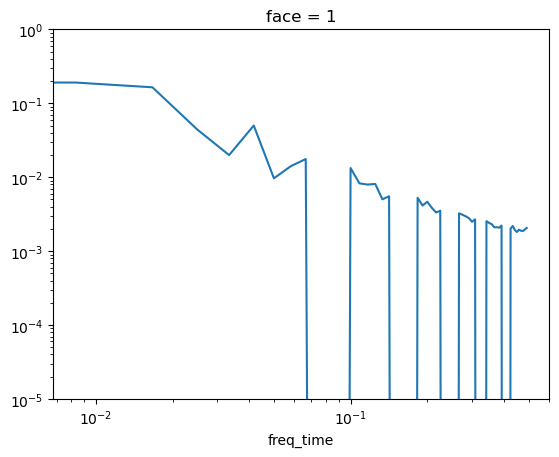

In [219]:
V_ps = xrft.power_spectrum(V_filtered.load(),dim='time').mean(['i','j_g'])
#U_ps[69:71]=0
#U_ps[79:81]=0
#U_ps[89:91]=0
#U_ps[99:100]=0
#V_ps[108:111]=0
V_ps[60:].plot()

plt.semilogx()
plt.semilogy()
plt.ylim([10**-5, 1])

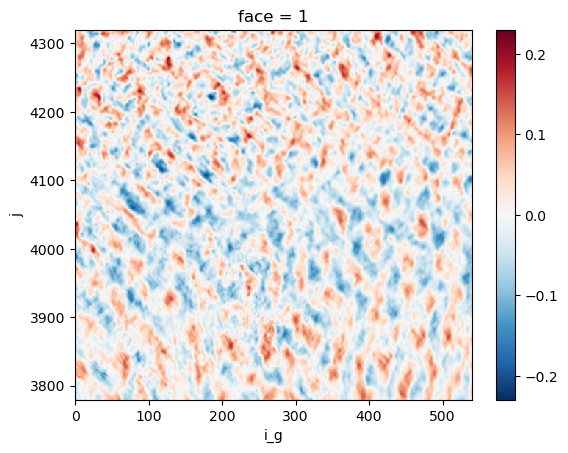

In [158]:
tidal_Utot.isel(time=59).plot()

/tmp/ipykernel_95/2132151314.py:34: RuntimeWarning: invalid value encountered in divide
  u_diff_x = (u[..., 1:] - u[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_95/2132151314.py:35: RuntimeWarning: invalid value encountered in divide
  v_diff_x = (v[..., 1:] - v[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_95/2132151314.py:36: RuntimeWarning: invalid value encountered in divide
  u_diff_y = (u[..., 1:, :] - u[..., :-1, :]) / dyc[..., 1:, :]
/tmp/ipykernel_95/2132151314.py:37: RuntimeWarning: invalid value encountered in divide
  v_diff_y = (v[..., 1:, :] - v[..., :-1, :]) / dyc[..., 1:, :]


In [161]:
#ζ_piece_eq_tidefree = vort(grid_eq, tide_free.U, ds_eq.dxC.load(), tide_free.V, ds_eq.dyC.load(), ds_eq.rAz.load(), axis= 5 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-5/2
#σ_piece_eq_tidefree = strain(grid_eq, tide_free.U, ds_eq.dxC.load(), tide_free.V, ds_eq.dyC.load(), axis=4 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-5/2
#D_piece_eq_tidefree = divergence(grid_eq, tide_free.U, ds_eq.dxG.load(), tide_free.V, ds_eq.dyG.load(), ds_eq.rA.load(), axis= 5 * [("Y", "X")])/10**-4

#ζ_piece_eq_tidefree4 = vort(grid_eq, tide_free4.U, ds_eq.dxC.load(), tide_free4.V, ds_eq.dyC.load(), ds_eq.rAz.load(), axis= 5 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-5/2
#σ_piece_eq_tidefree4 = strain(grid_eq, tide_free4.U, ds_eq.dxC.load(), tide_free4.V, ds_eq.dyC.load(), axis=4 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-5/2
#D_piece_eq_tidefree4 = divergence(grid_eq, tide_free4.U, ds_eq.dxG.load(), tide_free4.V, ds_eq.dyG.load(), ds_eq.rA.load(), axis= 5 * [("Y", "X")])/10**-4


ζ_piece_eq = vort(grid_eq, ds_eq.U, ds_eq.dxC.load(), ds_eq.V, ds_eq.dyC.load(), ds_eq.rAz.load(), axis= 5 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-5/2
σ_piece_eq = strain(grid_eq, ds_eq.U, ds_eq.dxC.load(), ds_eq.V, ds_eq.dyC.load(), axis=4 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-5/2
D_piece_eq = divergence(grid_eq, ds_eq.U, ds_eq.dxG.load(), ds_eq.V, ds_eq.dyG.load(), ds_eq.rA.load(), axis= 5 * [("Y", "X")])/10**-4

/tmp/ipykernel_95/2132151314.py:34: RuntimeWarning: invalid value encountered in divide
  u_diff_x = (u[..., 1:] - u[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_95/2132151314.py:35: RuntimeWarning: invalid value encountered in divide
  v_diff_x = (v[..., 1:] - v[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_95/2132151314.py:36: RuntimeWarning: invalid value encountered in divide
  u_diff_y = (u[..., 1:, :] - u[..., :-1, :]) / dyc[..., 1:, :]
/tmp/ipykernel_95/2132151314.py:37: RuntimeWarning: invalid value encountered in divide
  v_diff_y = (v[..., 1:, :] - v[..., :-1, :]) / dyc[..., 1:, :]


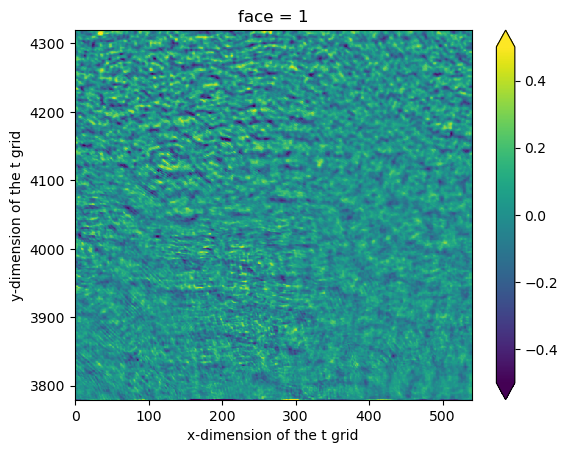

In [162]:
D_piece_eq_tideonly.isel(time=59).plot.pcolormesh(vmax=0.5,vmin=-0.5)

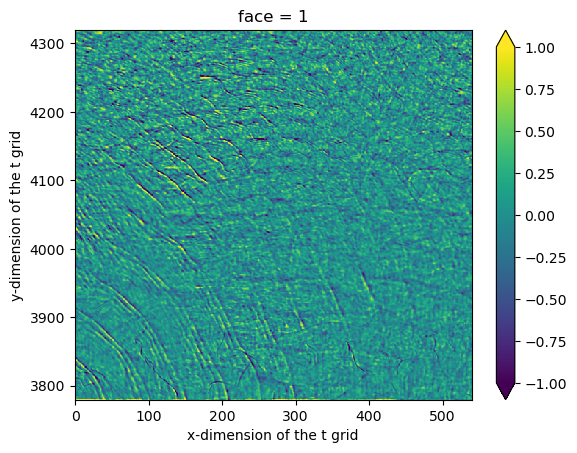

In [163]:
D_piece_eq.isel(time=59).plot.pcolormesh(vmax=1,vmin=-1)

In [35]:
h_eq = histogram(
    ζ_piece_eq.rename('vort'),
    σ_piece_eq.rename('strain'),
    D_piece_eq.rename('div'),
    bins=[vort_bins, strain_bins, div_bins],
    block_size=None,  # avoids a divide-by-zero bug in xhistogram's code for automatically determining block_size
    density=False,  # setting this to true leads to an error right now
    keep_coords=True,
)
h_eq = h_eq/a/550/550

h_eq_tidefree = histogram(
    ζ_piece_eq_tidefree.rename('vort'),
    σ_piece_eq_tidefree.rename('strain'),
    D_piece_eq_tidefree.rename('div'),
    bins=[vort_bins, strain_bins, div_bins],
    block_size=None,  # avoids a divide-by-zero bug in xhistogram's code for automatically determining block_size
    density=False,  # setting this to true leads to an error right now
    keep_coords=True,
)
h_eq_tidefree = h_eq_tidefree/a/550/550


h_eq_tidefree4 = histogram(
    ζ_piece_eq_tidefree4.rename('vort'),
    σ_piece_eq_tidefree4.rename('strain'),
    D_piece_eq_tidefree4.rename('div'),
    bins=[vort_bins, strain_bins, div_bins],
    block_size=None,  # avoids a divide-by-zero bug in xhistogram's code for automatically determining block_size
    density=False,  # setting this to true leads to an error right now
    keep_coords=True,
)
h_eq_tidefree4 = h_eq_tidefree4/a/550/550

In [36]:
h_vort_strain_eq = (h_eq.pdf.marginalize('div_bin')/97).load()
h_DivPdf_eq = (h_eq*h_eq.div_bin).mean('div_bin').load()

h_DivPdf_eq_tidefree = (h_eq_tidefree*h_eq_tidefree.div_bin).mean('div_bin').load()

h_DivPdf_eq_tidefree4 = (h_eq_tidefree4*h_eq_tidefree4.div_bin).mean('div_bin').load()

<>:11: SyntaxWarning: invalid escape sequence '\z'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\z'
<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\z'
<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\z'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\z'
<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\z'
<>:34: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1206/207825725.py:11: SyntaxWarning: invalid escape sequence '\z'
  plt.xlabel('$\zeta/f_{floor}$')
/tmp/ipykernel_1206/207825725.py:12: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma/f_{floor}$')
/tmp/ipykernel_1206/207825725.py:22: SyntaxWarning: invalid escape sequence '\z'
  plt.xlabel('$\zeta/f_{floor}$')
/tmp/ipykernel_1206/207825725.py:23: Synta

Text(0, 0.5, '$\\sigma/f_{floor}$')

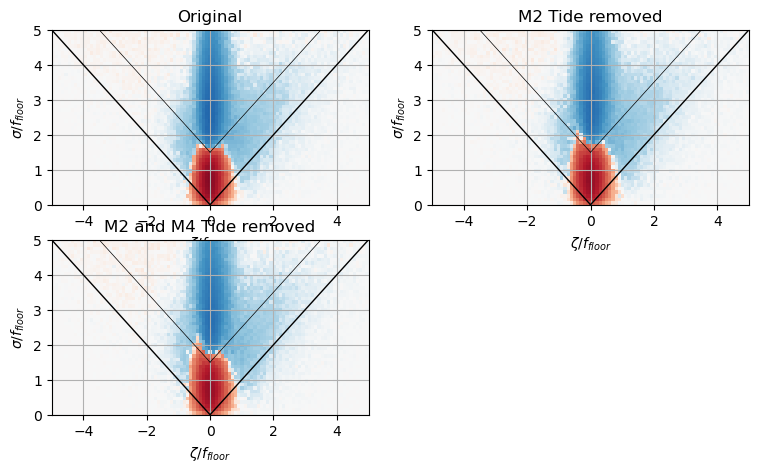

In [37]:
fig = plt.figure(figsize=(9, 5))

plt.subplot(221)
cs1=h_DivPdf_eq.plot.pcolormesh(x='vort_bin', vmax=0.5, norm=mpl.colors.SymLogNorm(1e-3),add_colorbar=False)
plt.title('Original')
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1)
plt.plot(np.linspace(0,3.5), np.linspace(1.5,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-3.5,0), np.linspace(5,1.5),color='k',linewidth=0.5)
plt.grid()
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')

plt.subplot(222)
cs1=h_DivPdf_eq_tidefree.plot.pcolormesh(x='vort_bin', vmax=0.5, norm=mpl.colors.SymLogNorm(1e-3),add_colorbar=False)
plt.title('M2 Tide removed')
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1)
plt.plot(np.linspace(0,3.5), np.linspace(1.5,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-3.5,0), np.linspace(5,1.5),color='k',linewidth=0.5)
plt.grid()
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')

plt.subplot(223)
cs1=h_DivPdf_eq_tidefree4.plot.pcolormesh(x='vort_bin', vmax=0.5, norm=mpl.colors.SymLogNorm(1e-3),add_colorbar=False)
plt.title('M2 and M4 Tide removed')
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1)
plt.plot(np.linspace(0,3.5), np.linspace(1.5,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-3.5,0), np.linspace(5,1.5),color='k',linewidth=0.5)
plt.grid()
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')

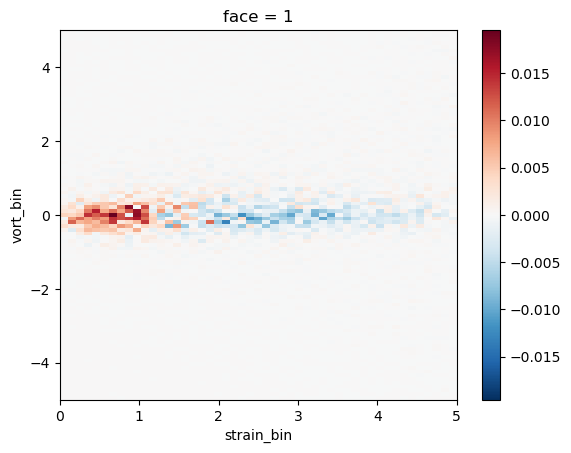

In [39]:
(h_DivPdf_eq_tidefree-h_DivPdf_eq_tidefree4).plot()